<a href="https://colab.research.google.com/github/LarrySnyder/ASJ/blob/main/compas/COMPAS_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMPAS Data

This notebook experiments on the ProPublica COMPAS dataset. It is based on https://afraenkel.github.io/fairness-book/content/04-compas.html.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load and Parse the Data

First, we will download the dataset and print the records for two defendants to get a sense of what the dataset contains.

The data were collected by ProPublica via the Freedom of Information Act. This dataset comes from pretrial detention hearings in Broward County, Florida, in 2013.

The variables we will use are: sex/gender, race/ethnicity, age, purpose of assessment (e.g. pretrial release), type of assessment (recidivism, violent recidivism), and the risk-score itself.

In [37]:
defendants = pd.read_csv('https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-raw.csv')

with pd.option_context('display.max_rows', 30):
    print(defendants.loc[[32647, 5032]].drop(['FirstName', 'LastName', 'MiddleName'], axis=1).T)

                                      32647               5032 
Person_ID                             60304               52305
AssessmentID                          69187               58972
Case_ID                               62725               53582
Agency_Text                        PRETRIAL           Probation
Sex_Code_Text                          Male                Male
Ethnic_Code_Text           African-American           Caucasian
DateOfBirth                        07/05/95            05/04/89
ScaleSet_ID                              22                  22
ScaleSet                 Risk and Prescreen  Risk and Prescreen
AssessmentReason                     Intake              Intake
Language                            English             English
LegalStatus                        Pretrial       Post Sentence
CustodyStatus                   Jail Inmate           Probation
MaritalStatus                        Single              Single
Screening_Date                 1/10/14 0

The COMPAS dataset contains three types of risk scores: risk of violence, risk of recidivism, and risk of failure to appear. We are only interested in risk of recidivism, so we will exclude all the other records. 

In [39]:
defendants = defendants[defendants.DisplayText == 'Risk of Recidivism']


The number of defendants screened by COMPAS for Risk of Recidivism is:

In [10]:
len(defendants)

20281

A few dozen records have COMPAS scores set to -1. Let's get rid of those records too.

In [41]:
defendants = defendants[defendants.DecileScore > 0]
len(defendants)

20245

## Basic Data Analysis

Let's do some basic data analysis. First we'll get a count of the number of defendants by "sex" and by "ethnicity" (the terms used in the dataset).

The plots show that almost 80% of defendants are male. Roughly 45% are African-American and 35% are Caucasian.

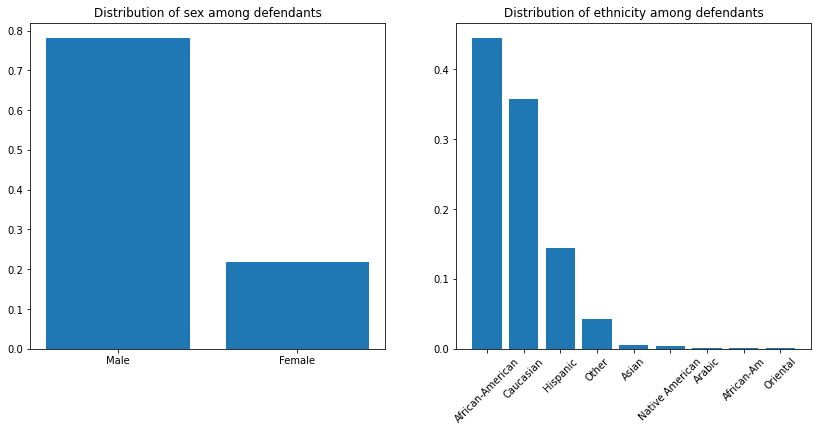

In [42]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

# Sex_Code_Text histogram.
sex_code_text_counts = defendants.Sex_Code_Text.value_counts(normalize=True)
axes[0].bar(sex_code_text_counts.index, sex_code_text_counts)
axes[0].set_title('Distribution of sex among defendants')

# Ethnic_Code_Text histogram.
ethnic_code_text_counts = defendants.Ethnic_Code_Text.value_counts(normalize=True)
axes[1].bar(ethnic_code_text_counts.index, ethnic_code_text_counts)
plt.xticks(rotation=45)
axes[1].set_title('Distribution of ethnicity among defendants');

Next, let's plot the COMPAS scores, i.e., the recidivism-risk "deciles" (scores on a 10-point scale).

The most frequent score is 1 (lowest risk), and the frequencies taper off from there.

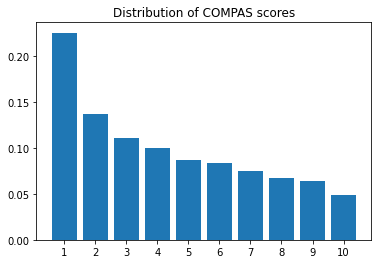

In [46]:
decilescore_counts = defendants.DecileScore.value_counts(normalize=True)
plt.bar(decilescore_counts.index, decilescore_counts)
plt.title('Distribution of COMPAS scores')
plt.xticks(range(1, 11));

There's a big difference between the distribution of scores for African-American defendants vs. Caucasian ones:

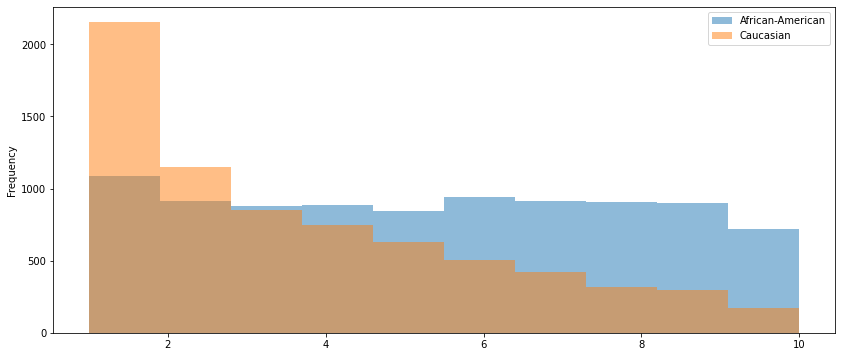

In [48]:
(
  defendants
  .loc[defendants.Ethnic_Code_Text.isin(['African-American', 'Caucasian'])]
  .groupby('Ethnic_Code_Text')
  .DecileScore
  .plot(kind='hist', alpha=0.5, legend=True, figsize=(14,6))
);